In [ ]:
import numpy as np                                      # Numerical operations (arrays, math, transforms)
import pandas as pd                                     # Data loading and time series handling
import matplotlib.pyplot as plt                          # Plotting library for EDA and forecast charts

from statsmodels.tsa.statespace.sarimax import SARIMAX   # SARIMA/ARIMA modeling via SARIMAX class
from statsmodels.tsa.holtwinters import ExponentialSmoothing  # Holt-Winters (ETS) model implementation
from statsmodels.tsa.stattools import adfuller           # Augmented Dickey-Fuller test for stationarity

from sklearn.metrics import mean_absolute_error, mean_squared_error  # Forecast error metrics (MAE/RMSE)

from prophet import Prophet                              # Prophet forecasting model

In [ ]:
# File path for the uploaded dataset in this environment
CSV_PATH = "Month_Value_1.csv"                          # Points to the uploaded CSV file

# Column names from the dataset (verified)
DATE_COL = "Period"                                     # Date column in the file
TARGET_COL = "Revenue"                                  # Target variable we will forecast

# Time series configuration (dataset is monthly)
FREQ = "MS"                                             # Monthly Start frequency (Month Start)
SEASON_LENGTH = 12                                      # Monthly data typically has yearly seasonality (12 months)

# Evaluation setup
TEST_RATIO = 0.2                                        # Use last 20% of observations as test
FUTURE_PERIODS = 12                                     # Forecast 12 months into the future after final fit

In [ ]:
df = pd.read_csv(CSV_PATH)                               # Load the CSV file into a pandas DataFrame
df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True)  # Parse dates; "01.01.2015" needs dayfirst=True
df = df.sort_values(DATE_COL)                            # Sort by date to ensure correct time order

df = df.rename(columns={TARGET_COL: "y"})                # Rename target column to "y" for consistency
df = df[[DATE_COL, "y"]]                                 # Keep only date and target columns (simplifies workflow)

ts = df.set_index(DATE_COL)["y"]                         # Create a time series (pandas Series) indexed by date
ts = ts.asfreq(FREQ)                                     # Enforce monthly frequency; missing months become NaN

print("Rows:", len(ts))                                  # Print total number of monthly records
print("Date range:", ts.index.min(), "to", ts.index.max())# Print date coverage
print("Frequency:", ts.index.freqstr)                    # Confirm frequency string (expect "MS")

Rows: 96
Date range: 2015-01-01 00:00:00 to 2022-12-01 00:00:00
Frequency: MS


In [ ]:
missing_before = ts.isna().sum()                         # Count missing values after enforcing monthly frequency
print("Missing values before fill:", missing_before)     # Display missing value count

ts_filled = ts.interpolate(method="time")                # Fill internal gaps by time interpolation
ts_filled = ts_filled.ffill()                            # Forward fill edge NaNs (if any) at the start
ts_filled = ts_filled.bfill()                            # Backward fill edge NaNs (if any) at the end

missing_after = ts_filled.isna().sum()                   # Count missing values after filling
print("Missing values after fill:", missing_after)       # Confirm series is complete

Missing values before fill: 32
Missing values after fill: 0


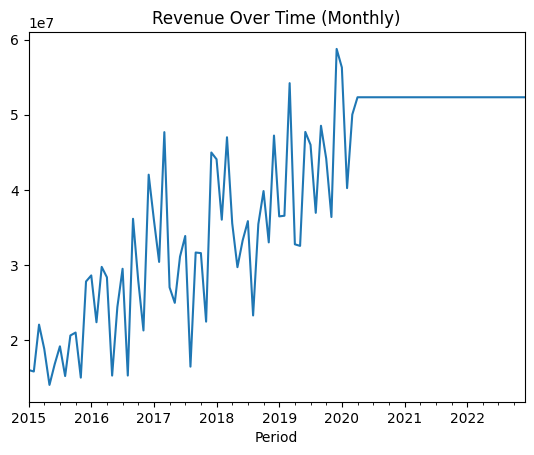

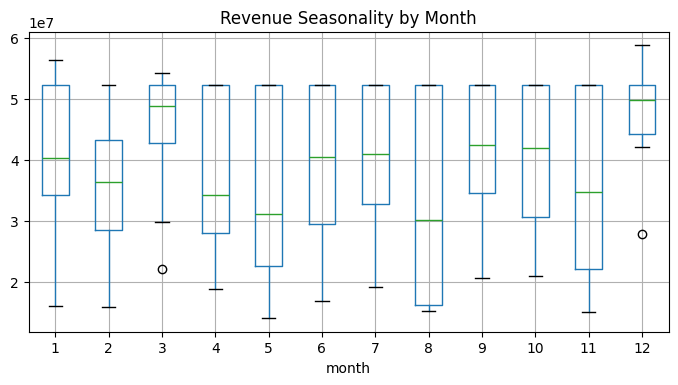

In [21]:
plt.figure()                                             # Create a new figure window
ts_filled.plot(title="Revenue Over Time (Monthly)")      # Plot the time series to view trend and patterns
plt.show()                                               # Render the plot

tmp = ts_filled.to_frame("y")                            # Convert Series to DataFrame for adding calendar features
tmp["month"] = tmp.index.month                           # Extract month number from the datetime index
tmp.boxplot(column="y", by="month", figsize=(8, 4))      # Boxplot by month to inspect seasonal pattern
plt.title("Revenue Seasonality by Month")                # Add a meaningful title
plt.suptitle("")                                         # Remove auto-generated pandas suptitle
plt.show()                                               # Render the plot


In [22]:
def adf_report(series, name="series"):                   # Define a helper function for ADF testing
    series = series.dropna()                             # Drop NaNs because ADF cannot handle missing values
    stat, pvalue, *_ = adfuller(series)                  # Run ADF and extract statistic and p-value
    print(f"ADF {name}: stat={stat:.3f}, p={pvalue:.4f} (p<0.05 suggests stationarity)")  # Print results

adf_report(ts_filled, "raw")                             # ADF on raw filled revenue series


ADF raw: stat=-1.707, p=0.4276 (p<0.05 suggests stationarity)


In [23]:
ts_log = np.log1p(ts_filled)                             # Apply log(1+x) to stabilize variance and handle zeros
adf_report(ts_log, "log")                                # ADF after log transform

ts_log_diff1 = ts_log.diff(1)                            # First differencing removes trend
adf_report(ts_log_diff1, "log diff(1)")                  # ADF after first differencing

ts_log_seasdiff = ts_log.diff(SEASON_LENGTH)             # Seasonal differencing removes yearly seasonality (12 months)
adf_report(ts_log_seasdiff, "log diff(12)")              # ADF after seasonal differencing


ADF log: stat=-2.755, p=0.0650 (p<0.05 suggests stationarity)
ADF log diff(1): stat=-3.748, p=0.0035 (p<0.05 suggests stationarity)
ADF log diff(12): stat=-2.682, p=0.0772 (p<0.05 suggests stationarity)


In [24]:
s = ts_filled.copy()                                     # Copy the series to avoid modifying the original
z = (s - s.mean()) / s.std()                             # Compute z-scores (distance from mean in std dev units)
s_clean = s.mask(z.abs() > 3)                            # Replace points with |z|>3 (extreme outliers) with NaN
s_clean = s_clean.interpolate("time")                    # Interpolate to fill removed outliers
s_clean = s_clean.ffill().bfill()                        # Fill any remaining edge NaNs

series = s_clean                                         # Choose cleaned series for modeling
print("NaNs in final modeling series:", series.isna().sum())  # Confirm no missing values remain


NaNs in final modeling series: 0


In [25]:
n_test = int(len(series) * TEST_RATIO)                   # Compute how many points go into the test set
train = series.iloc[:-n_test]                            # Training set: earlier portion of the series
test = series.iloc[-n_test:]                             # Test set: last portion (simulates future)

print("Train:", train.index.min(), "→", train.index.max(), "n=", len(train))  # Show train span
print("Test :", test.index.min(),  "→", test.index.max(),  "n=", len(test))   # Show test span


Train: 2015-01-01 00:00:00 → 2021-05-01 00:00:00 n= 77
Test : 2021-06-01 00:00:00 → 2022-12-01 00:00:00 n= 19


In [26]:
order = (1, 1, 1)                                        # ARIMA(p,d,q): baseline starting values
seasonal_order = (1, 1, 1, SEASON_LENGTH)                # Seasonal (P,D,Q,m): adds yearly seasonality (m=12)

sarima_model = SARIMAX(                                  # Create SARIMAX model object
    train,                                               # Training data (endogenous variable)
    order=order,                                         # Non-seasonal ARIMA order
    seasonal_order=seasonal_order,                       # Seasonal order for monthly seasonality
    enforce_stationarity=False,                          # Allow non-stationary settings (often helps fitting)
    enforce_invertibility=False                          # Allow non-invertible settings (often helps fitting)
)

sarima_fit = sarima_model.fit(disp=False)                # Fit the SARIMA model to training data
pred_sarima = sarima_fit.forecast(steps=len(test))       # Forecast for the length of the test period


In [27]:
hw_model = ExponentialSmoothing(                         # Create Holt-Winters model
    train,                                               # Training series
    trend="add",                                         # Additive trend component
    seasonal="add",                                      # Additive seasonal component
    seasonal_periods=SEASON_LENGTH                       # Season length = 12 months
)

hw_fit = hw_model.fit(optimized=True)                    # Fit smoothing parameters automatically
pred_hw = hw_fit.forecast(len(test))                     # Forecast over the test horizon


In [28]:
train_p = train.reset_index()                            # Convert datetime index back to a column
train_p.columns = ["ds", "y"]                            # Prophet requires columns named ds (date) and y (value)

prophet_model = Prophet(                                 # Initialize Prophet model
    yearly_seasonality=True,                             # Monthly data usually benefits from yearly seasonality
    weekly_seasonality=False,                            # Weekly seasonality not relevant for monthly data
    daily_seasonality=False                              # Daily seasonality not relevant for monthly data
)

prophet_model.fit(train_p)                               # Fit Prophet model on training data

future_df = prophet_model.make_future_dataframe(         # Create dataframe containing historical + future dates
    periods=len(test),                                   # Forecast horizon equals test size
    freq=FREQ                                             # Use monthly frequency ("MS")
)

prophet_fc = prophet_model.predict(future_df)            # Produce predictions for all dates in future_df
pred_prophet = prophet_fc.set_index("ds")["yhat"].iloc[-len(test):]  # Extract only test-horizon predictions
pred_prophet.index = test.index                          # Align prediction index with test index


22:40:31 - cmdstanpy - INFO - Chain [1] start processing
22:40:31 - cmdstanpy - INFO - Chain [1] done processing


In [29]:
def calc_metrics(y_true, y_pred):                        # Define metric function
    
    # Convert to numpy arrays (ensures alignment and avoids index issues)
    y_true = np.array(y_true)                            # Convert actual values to numpy array
    y_pred = np.array(y_pred)                            # Convert predictions to numpy array
    
    mae = mean_absolute_error(y_true, y_pred)            # Compute Mean Absolute Error
    
    mse = mean_squared_error(y_true, y_pred)             # Compute Mean Squared Error (no squared argument)
    rmse = np.sqrt(mse)                                  # Take square root manually to get RMSE
    
    # Avoid division by zero in MAPE
    denom = np.where(y_true == 0, np.nan, y_true)        # Replace zeros with NaN
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100  # Compute MAPE
    
    return {"MAE": mae, "RMSE": rmse, "MAPE%": mape}     # Return results as dictionary



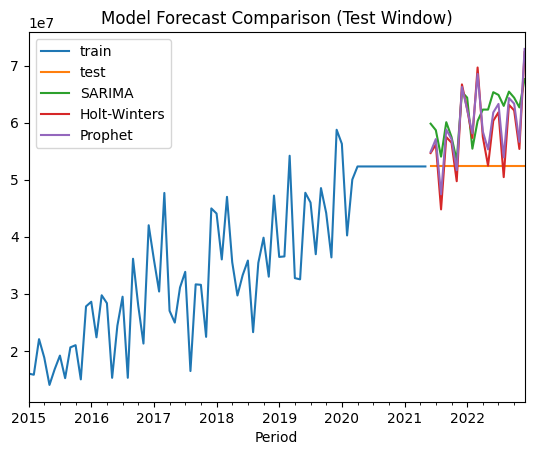

In [30]:
plt.figure()                                             # Create a new figure
train.plot(label="train")                                # Plot training data
test.plot(label="test")                                  # Plot actual test data

pd.Series(pred_sarima, index=test.index).plot(label="SARIMA")       # Plot SARIMA predictions
pd.Series(pred_hw, index=test.index).plot(label="Holt-Winters")     # Plot Holt-Winters predictions
pd.Series(pred_prophet, index=test.index).plot(label="Prophet")     # Plot Prophet predictions

plt.legend()                                             # Add legend for clarity
plt.title("Model Forecast Comparison (Test Window)")     # Title describing the plot
plt.show()                                               # Render the plot


In [ ]:
full = series                                            # Full cleaned series for final training

# SARIMA refit on full data
sarima_full = SARIMAX(                                   # Build SARIMA model on full history
    full,                                                # Full series
    order=order,                                         # Same ARIMA order used earlier
    seasonal_order=seasonal_order,                       # Same seasonal order used earlier
    enforce_stationarity=False,                          # Keep same fitting settings
    enforce_invertibility=False                          # Keep same fitting settings
).fit(disp=False)                                        # Fit model parameters

future_sarima = sarima_full.forecast(FUTURE_PERIODS)     # Forecast FUTURE_PERIODS months ahead

# Holt-Winters refit on full data
hw_full = ExponentialSmoothing(                          # Build ETS model on full history
    full,                                                # Full series
    trend="add",                                         # Additive trend
    seasonal="add",                                      # Additive seasonality
    seasonal_periods=SEASON_LENGTH                       # 12-month seasonality
).fit(optimized=True)                                    # Fit smoothing parameters

future_hw = hw_full.forecast(FUTURE_PERIODS)             # Forecast FUTURE_PERIODS months ahead

# Prophet refit on full data
full_p = full.reset_index()                              # Convert index to column for Prophet
full_p.columns = ["ds", "y"]                             # Rename columns for Prophet input

prophet_full = Prophet(                                  # Create Prophet model for full fit
    yearly_seasonality=True,                             # Use yearly seasonality for monthly series
    weekly_seasonality=False,                            # Not needed for monthly data
    daily_seasonality=False                              # Not needed for monthly data
)

prophet_full.fit(full_p)                                 # Fit Prophet on full data

future_df2 = prophet_full.make_future_dataframe(         # Create future dates dataframe
    periods=FUTURE_PERIODS,                               # Forecast horizon length
    freq=FREQ                                             # Monthly start frequency
)

fc2 = prophet_full.predict(future_df2)                   # Generate forecasts
future_prophet = fc2.set_index("ds")["yhat"].iloc[-FUTURE_PERIODS:]  # Extract only future horizon values


/Users/tdhraik/Documents/python/AI_Batch_11_Python_Assignments/.venv/lib/python3.14/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
22:40:31 - cmdstanpy - INFO - Chain [1] start processing
22:40:31 - cmdstanpy - INFO - Chain [1] done processing


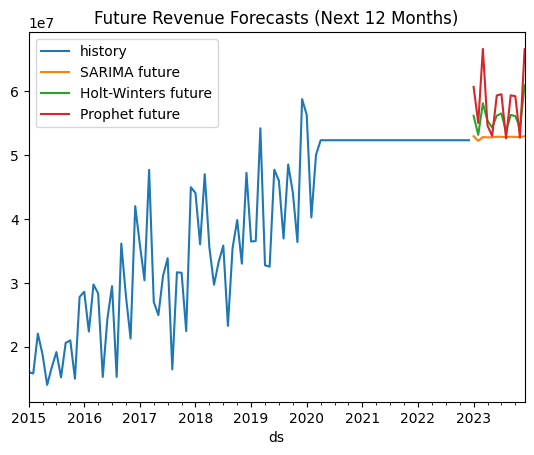

In [32]:
plt.figure()                                             # Create a new plot
full.plot(label="history")                               # Plot historical data for context

future_sarima.plot(label="SARIMA future")                # Plot SARIMA future forecast
future_hw.plot(label="Holt-Winters future")              # Plot Holt-Winters future forecast
future_prophet.plot(label="Prophet future")              # Plot Prophet future forecast

plt.legend()                                             # Add legend
plt.title("Future Revenue Forecasts (Next 12 Months)")   # Title for the chart
plt.show()                                               # Render the plot
